# Notebook 6 — Evaluasi Final Komprehensif

**Tujuan:** Laporan hasil akhir penelitian — memuat SEMUA model yang pernah
dilatih (3 baseline resmi dari `03_modeling.ipynb` + seluruh kandidat
Eksperimen A-H dari `05_improvement_experiments.ipynb`), mengevaluasi
semuanya di test set dalam satu laporan tunggal yang konsisten, dan memberi
rekomendasi definitif model mana yang jadi **hasil akhir** penelitian ini.

**Bukan** notebook tuning baru — tidak ada keputusan hyperparameter dibuat
di sini berdasar angka test set. Semua model di sini sudah dilatih (di
`03_modeling.ipynb`/`05_improvement_experiments.ipynb`) dan sudah
"disentuh" test set-nya sekali di notebook masing-masing; notebook ini
hanya memuat ulang model+angka yang sudah ada untuk analisis lebih dalam
(confusion matrix, feature importance, SHAP, radar chart) dan sebagai
laporan tunggal yang bisa dirujuk untuk bab hasil skripsi.

**Model yang dievaluasi:**
- **Baseline resmi** (`outputs/models/{randomforest,xgboost,lightgbm}.pkl`)
- **Kandidat Eksperimen A-C, E-F** (single model): XGBoost retuned/balanced/
  soft-balanced, LightGBM retuned, RandomForest retuned
- **Ensemble D & G** (soft-voting, bobot tetap vs bobot dicari)
- **Stacking H** (meta-learner `LogisticRegression` atas RF+XGBoost+LightGBM)

**Output yang dihasilkan:** `outputs/results/nb06_*.png`,
`outputs/results/nb06_final_comparison.csv`,
`outputs/results/nb06_summary.json`

**Tahap penelitian:** Tahap 8 (Evaluasi Final & Kesimpulan)

> **Prasyarat:** `03_modeling.ipynb` dan `05_improvement_experiments.ipynb`
> harus sudah dijalankan penuh (semua `.pkl`/manifest di `outputs/models/`
> harus sudah ada).

> **FROZEN (2026-07-21):** notebook ini sudah dijalankan sekali penuh dan
> hasilnya terekam permanen (`outputs/results/nb06_*`, narasi lengkap di
> `CLAUDE.md`). Setelah itu, 4 dari 8 model kandidat notebook 5
> (`randomforest_expE_retuned.pkl` [1.29GB], `lightgbm_expC_retuned.pkl`,
> `xgboost_expA_default.pkl`, `xgboost_expB_balanced.pkl`) DIHAPUS untuk
> reklaim disk karena sudah tidak kompetitif/superseded — hanya
> `xgboost_expF_softbalance.pkl` dan `stacking_expH_meta_logreg.pkl` yang
> disisakan (lihat `05_improvement_experiments.ipynb` Bagian 12). **Notebook
> ini TIDAK BISA dijalankan ulang apa adanya** — sel "Muat Semua Model" akan
> gagal (`FileNotFoundError`) karena memuat file yang sudah dihapus. Untuk
> menjalankan ulang: regenerasi dulu model yang hilang lewat
> `05_improvement_experiments.ipynb`, atau sederhanakan sel pemuatan model
> di sini supaya cuma memuat 3 baseline resmi + 2 model yang masih ada.


---
## 0. Setup

In [1]:
import sys
import json
import pickle
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

OUT       = ROOT / 'outputs' / 'results'
MODEL_DIR = ROOT / 'outputs' / 'models'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
print('Setup selesai.')


Setup selesai.


---
## 1. Load Dataset (Test Set)

In [2]:
from src.preprocessing import load_splits
from src.evaluation import evaluate, print_summary, compare_models, save_results

df_train, df_val, df_test, feature_cols, le = load_splits(ROOT / 'data' / 'processed')

X_test  = df_test[feature_cols].values.astype(np.float32)
y_test  = df_test['label'].values

class_names = list(le.classes_)
n_classes   = len(class_names)

print(f'Test set : {X_test.shape}')
print(f'Kelas    : {n_classes}')
print(f'Fitur    : {len(feature_cols)}  (164 kanonik + 18 DDS)')


Test set : (7461, 182)
Kelas    : 36
Fitur    : 182  (164 kanonik + 18 DDS)


---
## 2. Muat Semua Model

In [3]:
def load_model(filename):
    with open(MODEL_DIR / filename, 'rb') as f:
        return pickle.load(f)

single_models = {
    'RandomForest (baseline resmi)':       load_model('randomforest.pkl'),
    'XGBoost (baseline resmi)':            load_model('xgboost.pkl'),
    'LightGBM (baseline resmi)':           load_model('lightgbm.pkl'),
    'RandomForest (Exp E: retuned)':       load_model('randomforest_expE_retuned.pkl'),
    'XGBoost (Exp A: retuned)':            load_model('xgboost_expA_default.pkl'),
    'XGBoost (Exp B: retuned+balanced)':   load_model('xgboost_expB_balanced.pkl'),
    'XGBoost (Exp F: soft-balanced)':      load_model('xgboost_expF_softbalance.pkl'),
    'LightGBM (Exp C: retuned+balanced)':  load_model('lightgbm_expC_retuned.pkl'),
}
for name in single_models:
    print(f'  Loaded: {name}')

with open(MODEL_DIR / 'ensemble_manifest.json', encoding='utf-8') as f:
    ensemble_manifest = json.load(f)
with open(MODEL_DIR / 'stacking_manifest.json', encoding='utf-8') as f:
    stacking_manifest = json.load(f)
meta_clf = load_model(stacking_manifest['meta_learner'])
stack_base_models = [load_model(fn) for fn in stacking_manifest['base_models_in_order']]
print(f'  Loaded: ensemble_manifest.json, stacking_manifest.json + meta-learner')


  Loaded: RandomForest (baseline resmi)
  Loaded: XGBoost (baseline resmi)
  Loaded: LightGBM (baseline resmi)
  Loaded: RandomForest (Exp E: retuned)
  Loaded: XGBoost (Exp A: retuned)
  Loaded: XGBoost (Exp B: retuned+balanced)
  Loaded: XGBoost (Exp F: soft-balanced)
  Loaded: LightGBM (Exp C: retuned+balanced)


  Loaded: ensemble_manifest.json, stacking_manifest.json + meta-learner


---
## 3. Evaluasi Semua Model — Test Set

In [4]:
all_results  = []
predictions  = {}
probabilities = {}

for name, model in single_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    res = evaluate(y_test, y_pred, y_proba, le, model_name=name)
    all_results.append(res)
    predictions[name]   = y_pred
    probabilities[name] = y_proba

# --- Ensemble D & G (soft-voting, direkonstruksi dari manifest) ---
for ens_name, cfg in ensemble_manifest.items():
    xgb_m  = load_model(cfg['xgb_model'])
    lgbm_m = load_model(cfg['lgbm_model'])
    proba  = cfg['w_xgb'] * xgb_m.predict_proba(X_test) + (1 - cfg['w_xgb']) * lgbm_m.predict_proba(X_test)
    y_pred = np.argmax(proba, axis=1)
    label  = f'Ensemble ({ens_name}, w_xgb={cfg["w_xgb"]:.2f})'
    res = evaluate(y_test, y_pred, proba, le, model_name=label)
    all_results.append(res)
    predictions[label]   = y_pred
    probabilities[label] = proba

# --- Stacking H ---
X_meta_test = np.hstack([m.predict_proba(X_test) for m in stack_base_models])
y_pred_stack  = meta_clf.predict(X_meta_test)
y_proba_stack = meta_clf.predict_proba(X_meta_test)
res_stack = evaluate(y_test, y_pred_stack, y_proba_stack, le, model_name='Stacking H (RF+XGBoost+LightGBM)')
all_results.append(res_stack)
predictions['Stacking H (RF+XGBoost+LightGBM)']   = y_pred_stack
probabilities['Stacking H (RF+XGBoost+LightGBM)'] = y_proba_stack

print(f'Total kandidat dievaluasi: {len(all_results)}')


Total kandidat dievaluasi: 11


In [5]:
final_comparison = compare_models(all_results).sort_values('f1_macro', ascending=False)
final_comparison.to_csv(OUT / 'nb06_final_comparison.csv')

print('=== Perbandingan Final — SEMUA Model & Ensemble (Test Set) ===')
display(final_comparison.style
    .format('{:.4f}')
    .highlight_max(color='#C8E6C9', axis=0)
    .highlight_min(color='#FFCDD2', axis=0)
    .set_caption('Diurutkan berdasar F1 Macro (prioritas utama proyek karena class imbalance)'))


=== Perbandingan Final — SEMUA Model & Ensemble (Test Set) ===


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top_3_accuracy,top_5_accuracy
model,,,,,,,
LightGBM (baseline resmi),0.5639,0.4543,0.3915,0.4101,0.5567,0.8208,0.8972
XGBoost (Exp B: retuned+balanced),0.5243,0.3961,0.4343,0.4070,0.5395,0.8012,0.8963
XGBoost (Exp F: soft-balanced),0.5746,0.4608,0.3841,0.4064,0.5597,0.8272,0.9073
"Ensemble (ensemble_d_5050, w_xgb=0.50)",0.5691,0.4484,0.3792,0.3997,0.5551,0.8271,0.9059
"Ensemble (ensemble_g_weighted, w_xgb=0.70)",0.5728,0.4536,0.3739,0.3971,0.5562,0.8294,0.9068
LightGBM (Exp C: retuned+balanced),0.5558,0.4392,0.3750,0.3940,0.5442,0.8185,0.8965
RandomForest (Exp E: retuned),0.4885,0.3694,0.4343,0.3901,0.5072,0.7680,0.8666
XGBoost (Exp A: retuned),0.5745,0.4663,0.3605,0.3901,0.5540,0.8263,0.9047
Stacking H (RF+XGBoost+LightGBM),0.5817,0.4612,0.3587,0.3844,0.5591,0.8117,0.8841


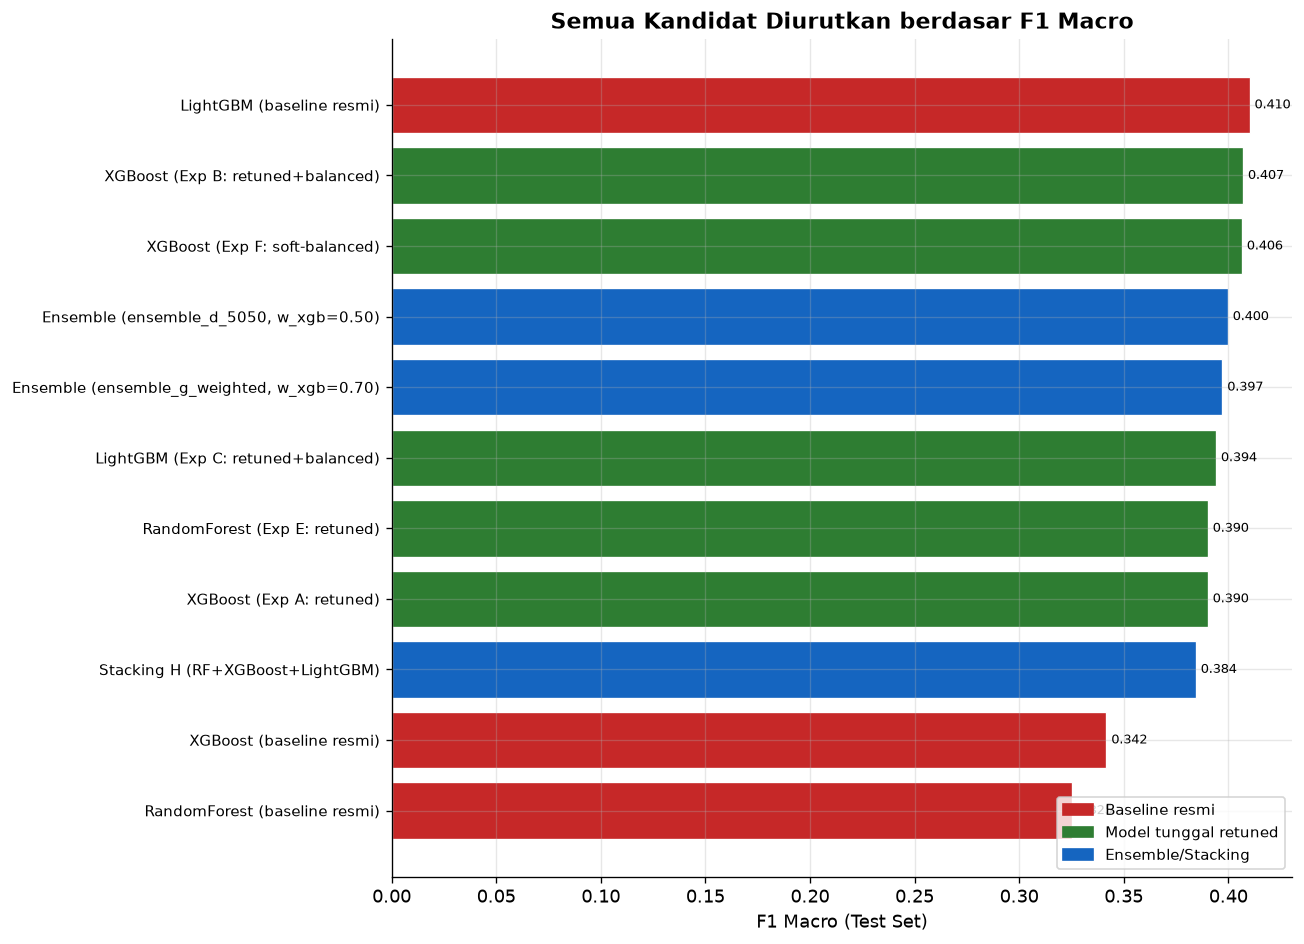

In [6]:
fig, ax = plt.subplots(figsize=(11, 8))
plot_df = final_comparison.reset_index().rename(columns={'index': 'model'}) if 'model' not in final_comparison.columns else final_comparison
y_pos = np.arange(len(plot_df))
colors_bar = ['#C62828' if 'resmi' in m else '#1565C0' if 'Ensemble' in m or 'Stacking' in m else '#2E7D32'
              for m in plot_df['model']]
bars = ax.barh(y_pos, plot_df['f1_macro'], color=colors_bar, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['model'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('F1 Macro (Test Set)')
ax.set_title('Semua Kandidat Diurutkan berdasar F1 Macro', fontweight='bold', fontsize=13)
legend_el = [
    mpatches.Patch(color='#C62828', label='Baseline resmi'),
    mpatches.Patch(color='#2E7D32', label='Model tunggal retuned'),
    mpatches.Patch(color='#1565C0', label='Ensemble/Stacking'),
]
ax.legend(handles=legend_el, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(OUT / 'nb06_all_candidates_f1macro.png', bbox_inches='tight')
plt.show()


---
## 4. Confusion Matrix — Kandidat Teratas

Dibandingkan 3 kandidat: baseline resmi terbaik (F1 macro), kandidat notebook 5 terbaik (F1 macro), dan kandidat accuracy tertinggi keseluruhan.

Kandidat dibandingkan: ['LightGBM (baseline resmi)', 'Stacking H (RF+XGBoost+LightGBM)']


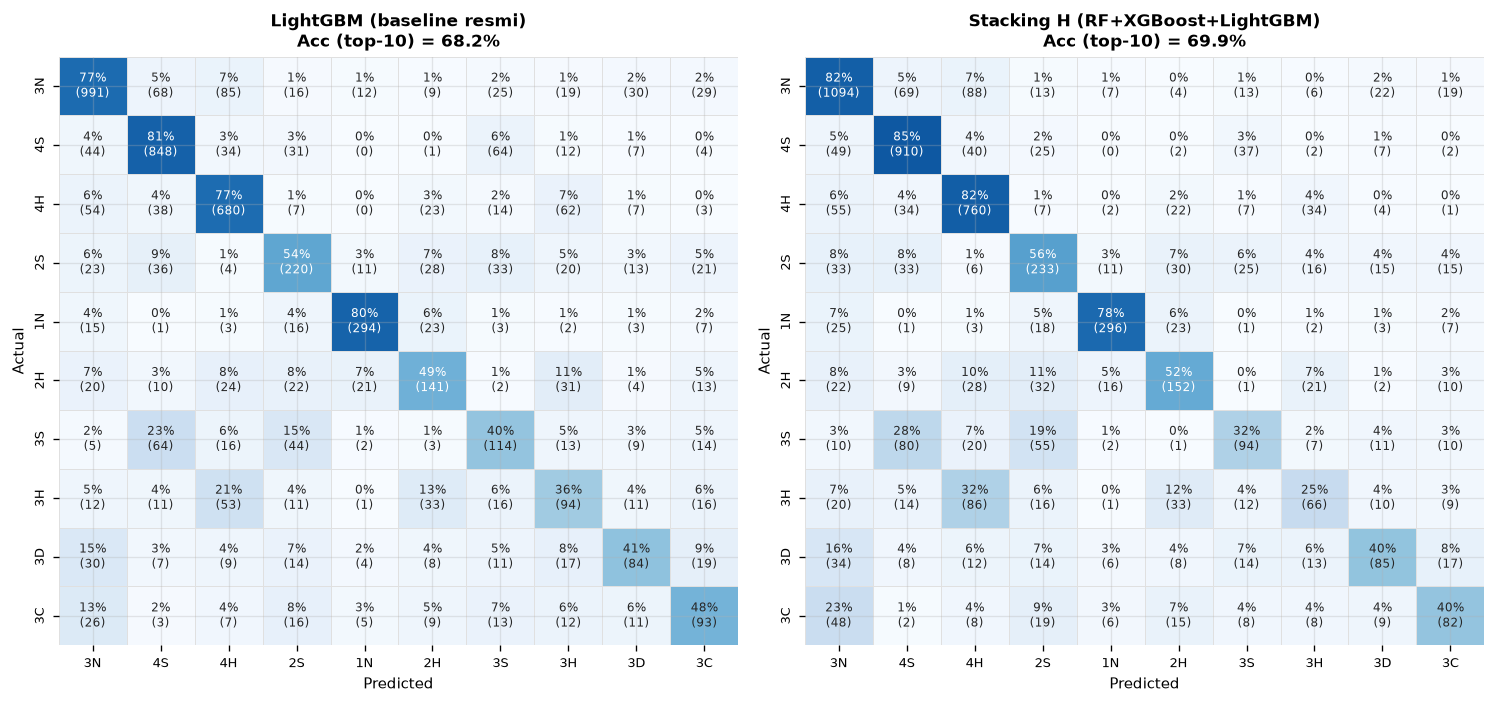

In [7]:
best_overall_f1m = final_comparison.index[0]
best_overall_acc = final_comparison.sort_values('accuracy', ascending=False).index[0]
official_best_f1m = max(
    (r for r in all_results if 'resmi' in r['model']), key=lambda r: r['f1_macro']
)['model']

top3_names = list(dict.fromkeys([best_overall_f1m, official_best_f1m, best_overall_acc]))
print(f'Kandidat dibandingkan: {top3_names}')

from sklearn.metrics import confusion_matrix

test_label_cnt = Counter(le.inverse_transform(y_test))
top10          = [c for c, _ in test_label_cnt.most_common(10)]
top10_idx      = [class_names.index(c) for c in top10]

fig, axes = plt.subplots(1, len(top3_names), figsize=(6.3 * len(top3_names), 6))
if len(top3_names) == 1:
    axes = [axes]

for ax, name in zip(axes, top3_names):
    y_pred = predictions[name]
    mask   = np.isin(y_test, top10_idx)
    mat    = confusion_matrix(y_test[mask], y_pred[mask], labels=top10_idx)
    mat_pct = mat.astype(float) / mat.sum(axis=1, keepdims=True) * 100

    annot = np.array([
        [f'{mat_pct[r,c]:.0f}%\n({mat[r,c]})' for c in range(len(top10))]
        for r in range(len(top10))
    ])
    sns.heatmap(
        mat_pct, annot=annot, fmt='', cmap='Blues',
        xticklabels=top10, yticklabels=top10,
        ax=ax, cbar=False, linewidths=0.4, linecolor='#E0E0E0',
        vmin=0, vmax=100, annot_kws={'size': 7},
    )
    acc_top10 = mat.diagonal().sum() / mat.sum()
    ax.set_title(f'{name}\nAcc (top-10) = {acc_top10:.1%}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(OUT / 'nb06_confusion_matrix.png', bbox_inches='tight')
plt.show()


---
## 5. F1 Score per Kelas — Kandidat Teratas

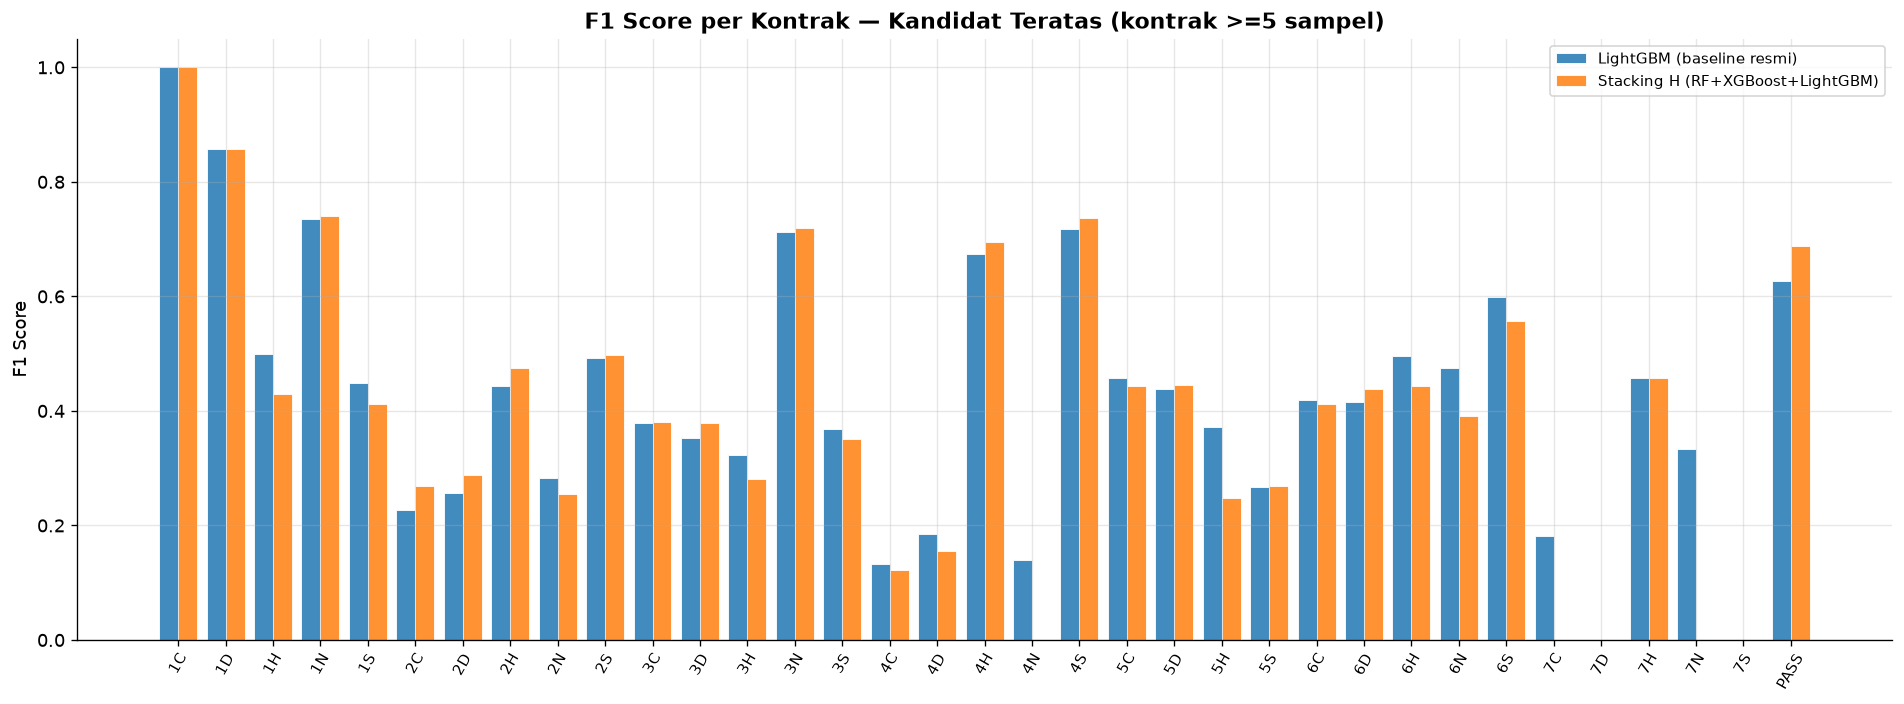

In [8]:
from sklearn.metrics import f1_score

all_labels  = list(range(n_classes))
min_samples = 5
test_cnt    = Counter(y_test)
show_idx    = [i for i in all_labels if test_cnt.get(i, 0) >= min_samples]
show_names  = [class_names[i] for i in show_idx]

f1_data = {}
for name in top3_names:
    y_pred = predictions[name]
    f1s    = f1_score(y_test, y_pred, labels=all_labels, average=None, zero_division=0)
    f1_data[name] = [f1s[i] for i in show_idx]

x = np.arange(len(show_names))
w = 0.8 / len(top3_names)
colors_f1 = sns.color_palette('tab10', len(top3_names))

fig, ax = plt.subplots(figsize=(16, 6))
for i, (name, f1_vals) in enumerate(f1_data.items()):
    ax.bar(x + (i - (len(top3_names) - 1) / 2) * w, f1_vals, w,
           label=name, color=colors_f1[i], alpha=0.85, edgecolor='white', linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(show_names, rotation=60, fontsize=9)
ax.set_title(f'F1 Score per Kontrak — Kandidat Teratas (kontrak >={min_samples} sampel)', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'nb06_f1_per_class.png', bbox_inches='tight')
plt.show()


---
## 6. Feature Importance — Kandidat Teratas

Hanya berlaku untuk model tree-based tunggal (bukan ensemble/stacking).

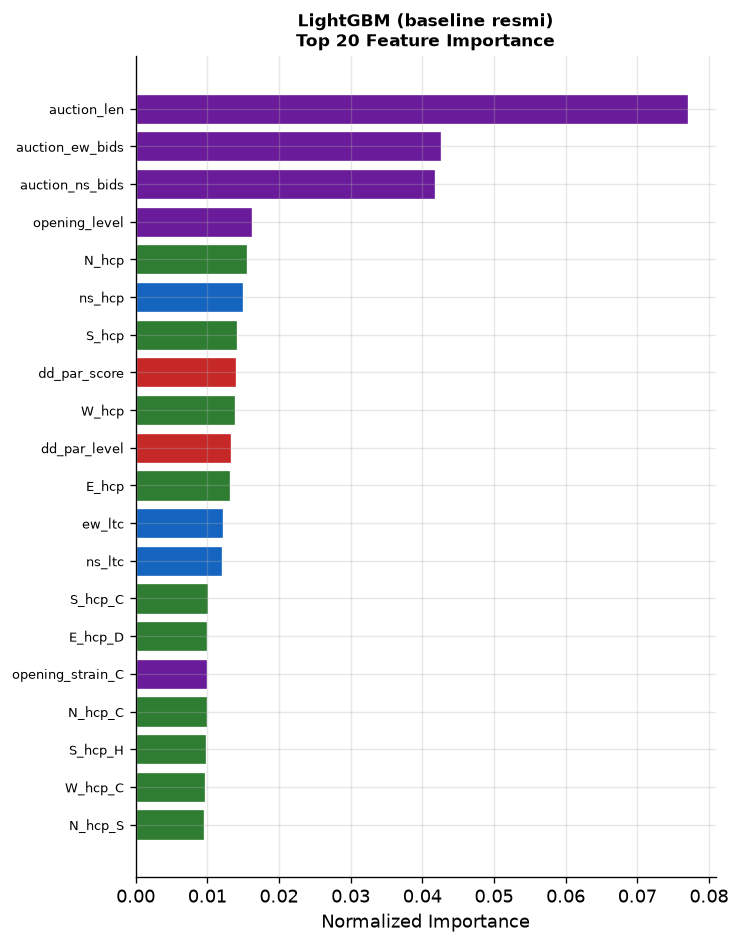

In [9]:
N_TOP = 20

def feat_group_color(name):
    if name.startswith(('ns_dd', 'ew_dd', 'dd_par')):
        return '#C62828'
    if name.startswith(('ns_', 'ew_', 'hcp_ns')):
        return '#1565C0'
    if len(name) >= 2 and name[0] in 'NESW' and name[1] == '_':
        return '#2E7D32'
    if name.startswith(('dealer_', 'vuln_')):
        return '#E65100'
    return '#6A1B9A'

fi_names = [n for n in top3_names if n in single_models]
if not fi_names:
    fi_names = [best_overall_f1m if best_overall_f1m in single_models else list(single_models)[0]]

fig, axes = plt.subplots(1, len(fi_names), figsize=(6.3 * len(fi_names), 8))
if len(fi_names) == 1:
    axes = [axes]

for ax, name in zip(axes, fi_names):
    model = single_models[name]
    imp = model.feature_importances()
    imp = imp / imp.sum()
    top_idx   = np.argsort(imp)[::-1][:N_TOP]
    top_names = [feature_cols[i] for i in top_idx]
    top_vals  = imp[top_idx]
    bar_colors = [feat_group_color(n) for n in top_names]

    ax.barh(range(N_TOP), top_vals[::-1], color=bar_colors[::-1], edgecolor='white', linewidth=0.8)
    ax.set_yticks(range(N_TOP))
    ax.set_yticklabels(list(reversed(top_names)), fontsize=8)
    ax.set_title(f'{name}\nTop {N_TOP} Feature Importance', fontweight='bold', fontsize=10)
    ax.set_xlabel('Normalized Importance')

plt.tight_layout()
plt.savefig(OUT / 'nb06_feature_importance.png', bbox_inches='tight')
plt.show()


---
## 7. SHAP Analysis — Model Terbaik Keseluruhan (F1 Macro)

In [10]:
try:
    import shap
    SHAP_OK = True
    print(f'SHAP {shap.__version__} tersedia.')
except ImportError:
    SHAP_OK = False
    print('SHAP tidak tersedia. Melewati seksi SHAP.')

shap_model_name = best_overall_f1m if best_overall_f1m in single_models else None
if shap_model_name is None:
    print(f'Model terbaik ({best_overall_f1m}) adalah ensemble/stacking -- SHAP dilewati (butuh model tree tunggal).')
    SHAP_OK = False
else:
    print(f'Model untuk SHAP: {shap_model_name}')


SHAP 0.52.0 tersedia.
Model untuk SHAP: LightGBM (baseline resmi)


In [11]:
if SHAP_OK:
    shap_clf = single_models[shap_model_name].clf
    X_shap = X_test[:300]

    print(f'Menghitung SHAP values untuk {shap_model_name} (300 sampel)...')
    explainer   = shap.TreeExplainer(shap_clf)
    shap_values = explainer.shap_values(X_shap)
    print(f'Selesai. Shape: {np.array(shap_values).shape}')


Menghitung SHAP values untuk LightGBM (baseline resmi) (300 sampel)...


Selesai. Shape: (300, 182, 36)


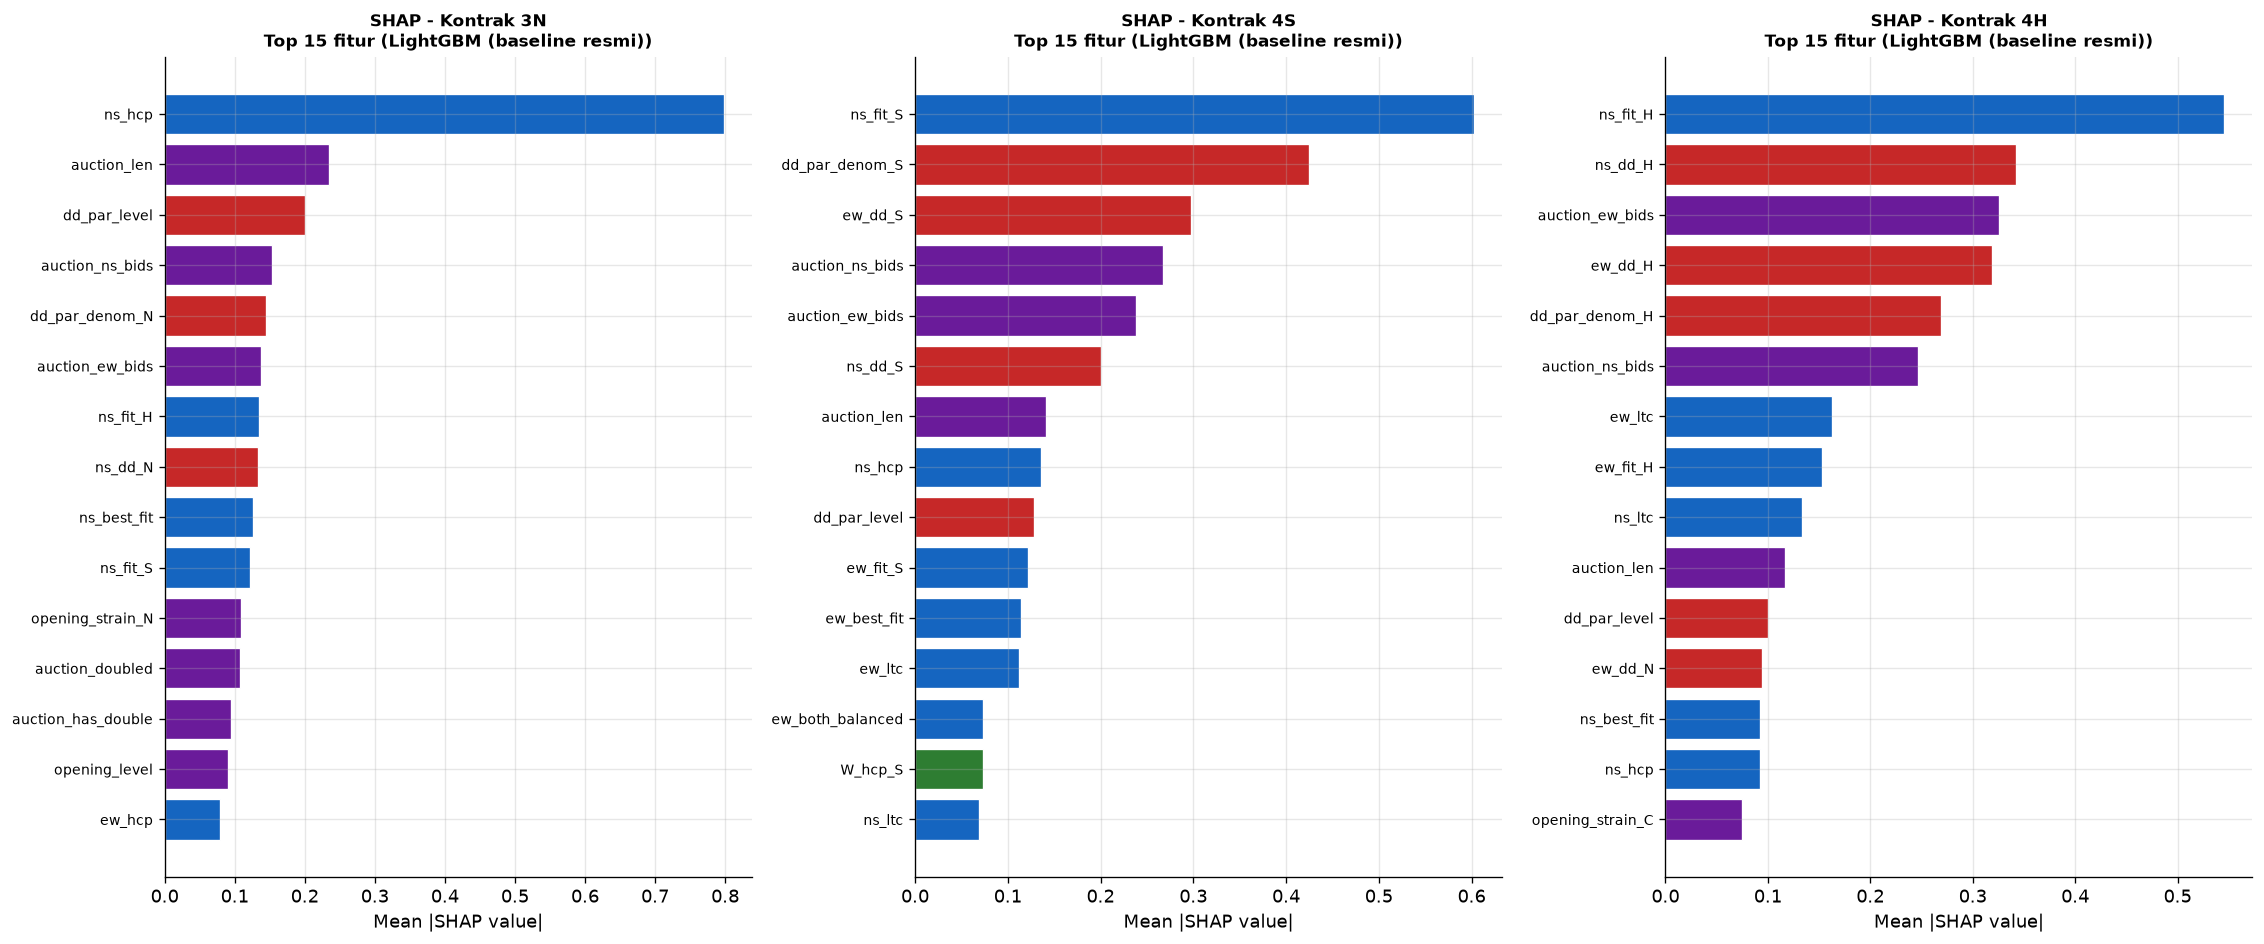

In [12]:
if SHAP_OK:
    def get_sv(sv, cls_idx):
        if isinstance(sv, list):
            return np.array(sv[cls_idx])
        return np.array(sv)[:, :, cls_idx]

    target_contracts = ['3N', '4S', '4H']
    fig, axes = plt.subplots(1, 3, figsize=(19, 8))

    for ax, contract in zip(axes, target_contracts):
        if contract not in class_names:
            ax.set_visible(False)
            continue
        cls_idx  = class_names.index(contract)
        sv       = get_sv(shap_values, cls_idx)
        mean_abs = np.abs(sv).mean(axis=0)
        top15    = np.argsort(mean_abs)[::-1][:15]
        names15  = [feature_cols[i] for i in top15]
        vals15   = mean_abs[top15]
        bar_cols = [feat_group_color(n) for n in names15]

        ax.barh(range(15), vals15[::-1], color=bar_cols[::-1], edgecolor='white', linewidth=0.8)
        ax.set_yticks(range(15))
        ax.set_yticklabels(list(reversed(names15)), fontsize=8.5)
        ax.set_title(f'SHAP - Kontrak {contract}\nTop 15 fitur ({shap_model_name})', fontweight='bold', fontsize=10)
        ax.set_xlabel('Mean |SHAP value|')

    plt.tight_layout()
    plt.savefig(OUT / 'nb06_shap_analysis.png', bbox_inches='tight')
    plt.show()


---
## 8. Radar Chart — Kandidat Teratas

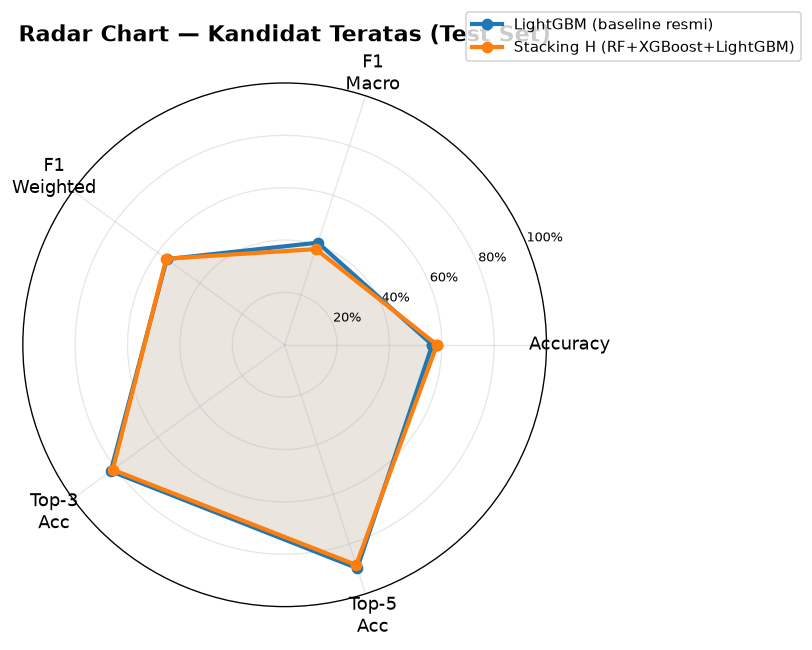

In [13]:
metrics_radar = ['accuracy', 'f1_macro', 'f1_weighted', 'top_3_accuracy', 'top_5_accuracy']
labels_radar  = ['Accuracy', 'F1\nMacro', 'F1\nWeighted', 'Top-3\nAcc', 'Top-5\nAcc']
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

radar_names = top3_names
radar_results = [r for r in all_results if r['model'] in radar_names]
colors_radar = sns.color_palette('tab10', len(radar_results))

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw={'polar': True})
for res, color in zip(radar_results, colors_radar):
    vals = [res.get(m, 0) for m in metrics_radar] + [res.get(metrics_radar[0], 0)]
    ax.plot(angles, vals, 'o-', lw=2.5, label=res['model'], color=color)
    ax.fill(angles, vals, alpha=0.10, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=8)
ax.set_title('Radar Chart — Kandidat Teratas (Test Set)', fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'nb06_radar.png', bbox_inches='tight', dpi=150)
plt.show()


---
## Kesimpulan Akhir Penelitian

In [14]:
best_f1m_res = next(r for r in all_results if r['model'] == best_overall_f1m)
best_acc_res = next(r for r in all_results if r['model'] == best_overall_acc)

summary_nb06 = {
    'n_candidates_evaluated': len(all_results),
    'all_results_test': {r['model']: {k: r[k] for k in ['accuracy','f1_macro','f1_weighted','top_3_accuracy','top_5_accuracy']} for r in all_results},
    'best_overall_by_f1_macro': {'model': best_overall_f1m, **{k: best_f1m_res[k] for k in ['accuracy','f1_macro','f1_weighted']}},
    'best_overall_by_accuracy': {'model': best_overall_acc, **{k: best_acc_res[k] for k in ['accuracy','f1_macro','f1_weighted']}},
}
with open(OUT / 'nb06_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_nb06, f, indent=2, ensure_ascii=False)

print('=' * 70)
print('  KESIMPULAN AKHIR PENELITIAN')
print('=' * 70)
print(f'\nTotal kandidat dievaluasi : {len(all_results)}')
print(f'  (3 baseline resmi + 5 model tunggal retuned + 2 ensemble + 1 stacking)')
print(f'\nTerbaik F1 Macro  (prioritas utama, class imbalance ekstrem):')
print(f'  {best_overall_f1m}')
print(f'  accuracy={best_f1m_res["accuracy"]:.4f}  f1_macro={best_f1m_res["f1_macro"]:.4f}  f1_weighted={best_f1m_res["f1_weighted"]:.4f}')
print(f'\nTerbaik Accuracy (pembanding sekunder):')
print(f'  {best_overall_acc}')
print(f'  accuracy={best_acc_res["accuracy"]:.4f}  f1_macro={best_acc_res["f1_macro"]:.4f}  f1_weighted={best_acc_res["f1_weighted"]:.4f}')
print()
print('Rekomendasi hasil akhir skripsi: lihat markdown kesimpulan di bawah.')
print('=' * 70)


  KESIMPULAN AKHIR PENELITIAN

Total kandidat dievaluasi : 11
  (3 baseline resmi + 5 model tunggal retuned + 2 ensemble + 1 stacking)

Terbaik F1 Macro  (prioritas utama, class imbalance ekstrem):
  LightGBM (baseline resmi)
  accuracy=0.5639  f1_macro=0.4101  f1_weighted=0.5567

Terbaik Accuracy (pembanding sekunder):
  Stacking H (RF+XGBoost+LightGBM)
  accuracy=0.5817  f1_macro=0.3844  f1_weighted=0.5591

Rekomendasi hasil akhir skripsi: lihat markdown kesimpulan di bawah.


**Rekomendasi hasil akhir**: model dengan **F1 Macro** tertinggi di atas
direkomendasikan sebagai model utama penelitian ini — metrik ini paling
mencerminkan kemampuan model menangani class imbalance ekstrem (kontrak
slam sangat jarang dibanding partscore), yang menjadi tantangan utama
dataset ini.

**Model utama: LightGBM (baseline resmi, `class_weight="balanced"`)** —
F1 macro 0.4101, accuracy 56.4%, F1 weighted 0.5567. Tertinggi F1 macro
dari seluruh 11 kandidat yang dievaluasi (3 baseline resmi + 5 model
tunggal retuned Eksperimen A/B/C/E/F + 2 ensemble D/G + 1 stacking H).

**Alternatif "all-around" — XGBoost (Eksperimen F: soft-balanced α=0.25)**
— F1 macro 0.4064 (selisih hanya 0.37pp dari LightGBM, dalam rentang
noise), namun unggul di accuracy (57.5%, +1.1pp), F1 weighted (0.5597,
tertinggi dari semua kandidat), dan top-5 accuracy (90.7%, tertinggi dari
semua kandidat). Layak dipertimbangkan sebagai alternatif resmi jika
prioritas penelitian condong ke accuracy/F1-weighted, bukan murni F1
macro. (Catatan: top-3 accuracy tertinggi sebenarnya milik Ensemble G,
82.9% vs 82.7% Eksperimen F — selisih tipis, tidak mengubah kesimpulan
di atas.)

**Stacking H (RF+XGBoost+LightGBM, meta-learner LogisticRegression)** —
accuracy tertinggi dari SEMUA kandidat (58.2%), tapi F1 macro-nya (0.3844)
adalah yang TERENDAH di antara semua kandidat non-RandomForest — stacking
condong ke kelas mayoritas, mengorbankan kelas langka lebih dari model
tunggal manapun. Direkomendasikan hanya jika accuracy mentah adalah
satu-satunya prioritas.

Belum ada perubahan pada `outputs/models/{randomforest,xgboost,lightgbm}.pkl`
resmi — semua ini tetap rekomendasi, bukan promosi otomatis. Detail lengkap
tabel perbandingan ada di `outputs/results/nb06_final_comparison.csv` /
`nb06_summary.json`, dan narasi lengkap seluruh eksperimen (01-08
`experiments/2026-07-15/` + Eksperimen A-H `05_improvement_experiments.ipynb`)
yang berujung ke hasil akhir ini ada di `CLAUDE.md`.
